In [1]:
import os

import torch
from torch.utils.data import Dataset, DataLoader  # Pytorch의 데이터셋 관련
from torchvision import transforms  # 전처리모듈

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

from lxml import etree

In [2]:

# ## 데이터 준비
# # DATA_DIR = './_data/'
# DATA_DIR = './data/Astrophysics'
# ## 이미지 전처리 관련 인스턴스
# ## - 이미지 텐서화 및 타입 설정

# transform = transforms.Compose(
#     [   
#         transforms.PILToTensor(),  ## PIL.ToTensor 사용 ToTensor와는 다름.
#                                     ## PIL의 Image 객체를 텐서화
#         transforms.ConvertImageDtype(dtype=torch.float)  ## Image 텐서 타입 설정
#     ]
    
# )


In [3]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

DATA_DIR = './data/Astrophysics'
transform = A.Compose([
    # A.CenterCrop(240, 320),                            # 바운딩 박스 포함 중심 자르기
    # A.CenterCrop(480, 640),                            # 바운딩 박스 포함 중심 자르기
    # A.CenterCrop(120, 160),                            # 바운딩 박스 포함 중심 자르기
    A.Resize(24, 24),                          
    A.Normalize(mean=(0.485, 0.456, 0.406),            # torchvision 이미지넷 기본값
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),                                      # PIL → Tensor + dtype 변환 포함
], 
    bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'])
)


In [4]:
# ## stasndard class x_rayDataset(Dataset):
# class x_rayDataset(Dataset):
#     def __init__(self, image_root, xml_root, transform=None):
#         super().__init__()
#         self.image_root = image_root
#         self.xml_root = xml_root
#         self.transform = transform

#         self.flist = ['Firecracker', 'Hammer', 'NailClippers', 'Spanner', 'Thinner', 'ZippoOil']
#         self.class2idx = {name: idx+1 for idx, name in enumerate(self.flist)}
#         self.class2idx["unknown"] = 0

#         self.data = self._load_metadata()  # 이미지 경로와 XML 경로만 저장

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, index):
#         img_path, xml_path = self.data[index]
#         image = Image.open(img_path).convert("RGB")

#         # XML 파싱
#         boxes, labels = [], []
#         tree = etree.parse(xml_path)
#         root = tree.getroot()

#         for obj in root.findall('object'):
#             label = obj.find('name').text
#             label = label if label in self.flist else "unknown"
#             bbox = obj.find('bndbox')
#             xmin = int(bbox.find('xmin').text)
#             ymin = int(bbox.find('ymin').text)
#             xmax = int(bbox.find('xmax').text)
#             ymax = int(bbox.find('ymax').text)
#             # xmin = int(bbox.find('xmin').text)//3
#             # ymin = int(bbox.find('ymin').text)//3
#             # xmax = int(bbox.find('xmax').text)//3
#             # ymax = int(bbox.find('ymax').text)//3
#             boxes.append([xmin, ymin, xmax, ymax])
#             labels.append(self.class2idx[label])

#         target = {
#             "boxes": torch.FloatTensor(boxes),
#             "labels": torch.LongTensor(labels)
#         }

#         if self.transform:
#             image = self.transform(image)

#         return image, target

#     def _load_metadata(self):
#         data = []
#         for dirpath, _, filenames in os.walk(self.image_root):
#             for fname in filenames:
#                 if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
#                     continue

#                 img_path = os.path.join(dirpath, fname)
#                 xml_path = os.path.join(self.xml_root, os.path.splitext(fname)[0] + ".xml")

#                 if not os.path.exists(xml_path):
#                     continue  # 해당 XML이 없으면 스킵

#                 data.append((img_path, xml_path))
#         return data


In [5]:
## A class x_rayDataset(Dataset):
class x_rayDataset(Dataset):
    def __init__(self, image_root, xml_root, transform=None):
        super().__init__()
        self.image_root = image_root
        self.xml_root = xml_root
        self.transform = transform

        self.flist = ['Firecracker', 'Hammer', 'NailClippers', 'Spanner', 'Thinner', 'ZippoOil']
        self.class2idx = {name: idx+1 for idx, name in enumerate(self.flist)}
        # self.class2idx = {name: idx+1 for idx, name in enumerate(self.flist)}
        self.class2idx["unknown"] = 0

        self.data = self._load_metadata()  # 이미지 경로와 XML 경로만 저장

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        img_path, xml_path = self.data[index]
        image = Image.open(img_path).convert("RGB")

        # XML 파싱
        boxes, labels = [], []
        tree = etree.parse(xml_path)
        root = tree.getroot()

        for obj in root.findall('object'):
            label = obj.find('name').text
            label = label if label in self.flist else "unknown"
            bbox = obj.find('bndbox')
            xmin = int(bbox.find('xmin').text)
            ymin = int(bbox.find('ymin').text)
            xmax = int(bbox.find('xmax').text)
            ymax = int(bbox.find('ymax').text)
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(self.class2idx[label])

        # 변환 전 target 생성
        target = {
            "boxes": boxes,
            "labels": labels
        }

        # Albumentations 변환
        if self.transform:
            transformed = self.transform(
                image=np.array(image),
                bboxes=target['boxes'],
                labels=target['labels']
            )
            image = transformed['image']

            # 빈 box 처리
            if len(transformed['bboxes']) == 0:
                boxes_tensor = torch.zeros((0, 4), dtype=torch.float32)
                labels_tensor = torch.zeros((0,), dtype=torch.long)
            else:
                boxes_tensor = torch.tensor(transformed['bboxes'], dtype=torch.float32)
                labels_tensor = torch.tensor(np.array(transformed['labels'], dtype=np.int64))

            target = {
                "boxes": boxes_tensor,
                "labels": labels_tensor
            }
        else:
            # 변환이 없을 경우도 텐서화 해줘야 함
            if len(boxes) == 0:
                boxes_tensor = torch.zeros((0, 4), dtype=torch.float32)
                labels_tensor = torch.zeros((0,), dtype=torch.long)
            else:
                boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
                labels_tensor = torch.tensor(np.array(transformed['labels'], dtype=np.int64))

            target = {
                "boxes": boxes_tensor,
                "labels": labels_tensor
            }

        return image, target


    def _load_metadata(self):
        data = []
        for dirpath, _, filenames in os.walk(self.image_root):
            for fname in filenames:
                if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    continue

                img_path = os.path.join(dirpath, fname)
                xml_path = os.path.join(self.xml_root, os.path.splitext(fname)[0] + ".xml")

                if not os.path.exists(xml_path):
                    continue  # 해당 XML이 없으면 스킵

                data.append((img_path, xml_path))
        return data


In [6]:
trainDS = x_rayDataset(
    image_root='./data/Astrophysics/',
    ## train image 경로
    xml_root=r"./data/Annotation/Pascal/Astrophysics/",
    ## train xml 경로
    transform=transform
)
validDS = x_rayDataset(
    image_root='./data/testData/',
    ## test image 경로
    xml_root=r"./data/Annotation/Eval/Label/Pascal/AstroPhysics/",
    ## test xml 경로
    transform=transform
)



In [7]:
img, target = trainDS[0]
print(len(img), target)

print(f'[trainDS] 개수 : {len(trainDS)}개 ')
print(f'[validDS] 개수  : {len(validDS)}개 ')

3 {'boxes': tensor([[15.1125,  8.8000, 15.6375, 10.5111]]), 'labels': tensor([1])}
[trainDS] 개수 : 3300개 
[validDS] 개수  : 680개 


In [8]:
img.shape

torch.Size([3, 24, 24])

In [9]:
## 배치 데이터 생성 함수
## ---------------------------------------------------------
## 함수기능 : 개별 샘플을 미니배치로 결합하는 역할
## 함수이름 : collator
## 매개변수 : 배치크기
## 반환결과 : 배치크기만큼 연결된 데이터
## ---------------------------------------------------------
def collator(batch):
    return tuple(zip(*batch))

In [10]:
## 클래스 변환 Dict 생성
idx2class ={value:key for key, value in trainDS.class2idx.items()}
IDX_TO_CATEGORY = idx2class
print(IDX_TO_CATEGORY)
## 학습용 테스트용 데이터 확인
print(f'[trainDS] 개수 : {len(trainDS)}개 ')
print(f'[validDS] 개수  : {len(validDS)}개 ')
## 학습용 데이터셋에서 이미지 1개
imgTS, targetDict = trainDS[0]  ## <== __getitem__(indx)
print(imgTS.shape, targetDict.keys())

{1: 'Firecracker', 2: 'Hammer', 3: 'NailClippers', 4: 'Spanner', 5: 'Thinner', 6: 'ZippoOil', 0: 'unknown'}
[trainDS] 개수 : 3300개 
[validDS] 개수  : 680개 
torch.Size([3, 24, 24]) dict_keys(['boxes', 'labels'])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


torch.Size([3, 24, 24]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (10, 8, 4, 5)


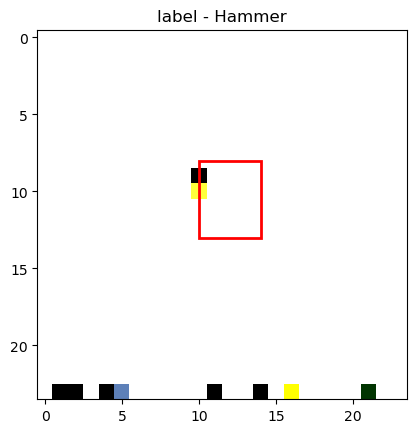

torch.Size([3, 24, 24]) dict_keys(['boxes', 'labels'])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


lx, ly, w, h => (11, 8, 3, 6)


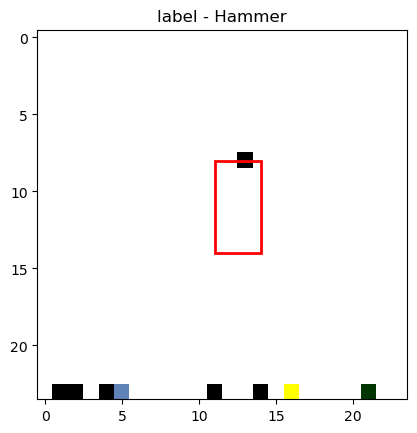

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


torch.Size([3, 24, 24]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (9, 7, 3, 8)


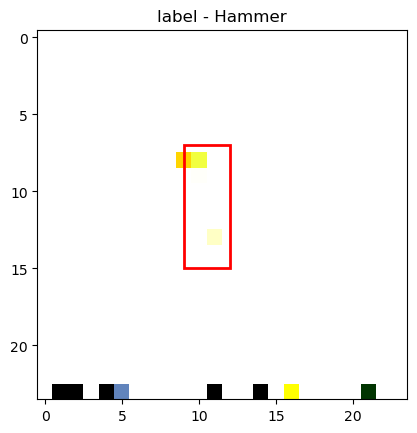

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


torch.Size([3, 24, 24]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (10, 8, 4, 3)


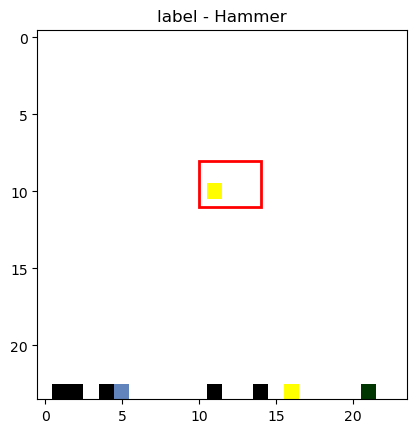

torch.Size([3, 24, 24]) dict_keys(['boxes', 'labels'])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


lx, ly, w, h => (10, 8, 2, 6)


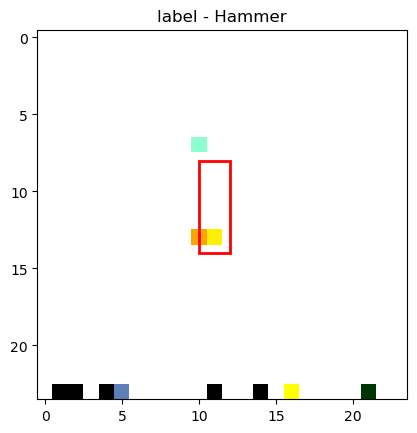

torch.Size([3, 24, 24]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (13, 9, 4, 4)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


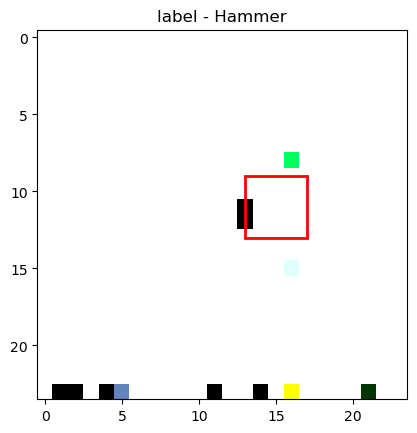

torch.Size([3, 24, 24]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (12, 9, 3, 6)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


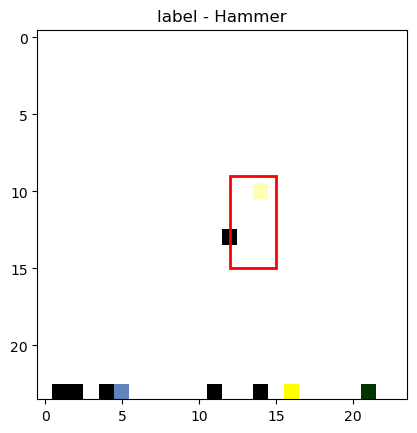

torch.Size([3, 24, 24]) dict_keys(['boxes', 'labels'])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


lx, ly, w, h => (11, 8, 4, 5)


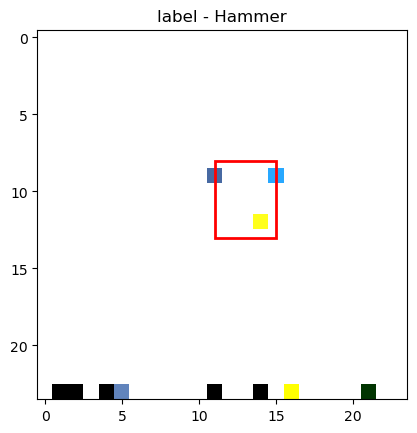

torch.Size([3, 24, 24]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (9, 8, 4, 5)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


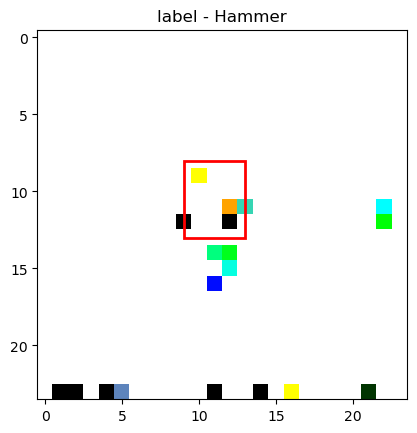

torch.Size([3, 24, 24]) dict_keys(['boxes', 'labels'])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


lx, ly, w, h => (10, 12, 4, 3)


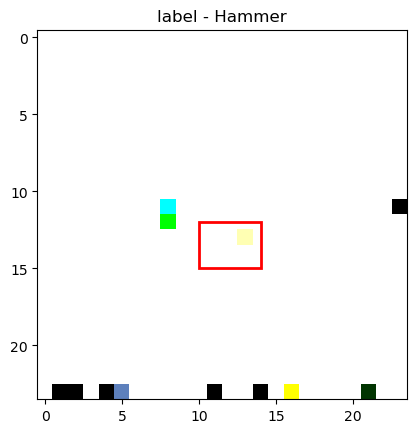

In [11]:

for i in range(1210, 1220):
    imgTS, targetDict = trainDS[i]  ## <== __getitem__(indx)
    print(imgTS.shape, targetDict.keys())
    # - 라벨 정보 추출
    label = targetDict['labels'].item()

    # - 객체 위치 정보 추출
    lx, ly, rx, ry = [round(data.item()) for data in targetDict['boxes'].reshape(-1)]
    w, h = rx - lx, ry - ly

    print(f'lx, ly, w, h => {lx, ly, w, h}')
    ## 시각화 및 바운딩 박스
    plt.imshow(imgTS.permute(1, 2, 0))
    plt.title(f'label - {IDX_TO_CATEGORY[label]}')

    ## 바운딩 박스 추가
    ax = plt.gca()  #- get current axis
    ax.add_patch(patches.Rectangle((lx, ly), w, h, color='red', linewidth=2, fill=False))

    plt.show()

In [12]:

TBATCH_SIZE = 16
VBATCH_SIZE = 2
NUM_WORKER = 4

In [13]:
# TRAIN_DL = DataLoader( trainDS, batch_size=TBATCH_SIZE, shuffle=True, drop_last=True, collate_fn=collator,num_workers=NUM_WORKER)
# VALID_DL  = DataLoader( validDS,  batch_size=VBATCH_SIZE, shuffle=True, drop_last=True, collate_fn=collator ,num_workers=NUM_WORKER)
TRAIN_DL = DataLoader( trainDS, batch_size=TBATCH_SIZE, shuffle=True, drop_last=True, collate_fn=collator)
VALID_DL  = DataLoader( validDS,  batch_size=VBATCH_SIZE, shuffle=True, drop_last=True, collate_fn=collator)

In [14]:
# cnum = 0
# for a,b in TRAIN_DL:
#     cnum += 1
#     if cnum ==105: break
#     print(len(a))
#     # print(b['boxes'].shape)
#     print(cnum)
#     print(b[0]['boxes'].shape)
    

In [15]:
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.models.detection.retinanet import RetinaNet_ResNet50_FPN_Weights, ResNet50_Weights


In [16]:
# weights 설정
WEIGHTS = RetinaNet_ResNet50_FPN_Weights.DEFAULT

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# 모델 로딩 (pretrained backbone 포함)
MODEL = retinanet_resnet50_fpn(
    weights=None,  # 전체 모델은 초기화
    weights_backbone=ResNet50_Weights.DEFAULT,
    num_classes=7  # 여기서 원하는 클래스 수 지정
).to(DEVICE)

In [17]:
DEVICE

'cpu'

In [18]:
from torch import optim


params = [p for p in MODEL.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm  # tqdm 추가

In [20]:

## 모델 관련 모듈 로딩
from torchvision.models import vgg16, VGG16_Weights             ## 성능 개선 위해 변경 가능 
from torchvision.models.detection import rpn, FasterRCNN
from torchvision import ops
## --------------------------------------------------------------
## 모델 관련 설정들
## --------------------------------------------------------------

## - Backbone Network 관련
WEIGHTS     = VGG16_Weights.DEFAULT
BACKBONE    = vgg16(weights=WEIGHTS).features
BACKBONE.out_channels = 512
## vgg의 마지막 채널이 512임

## - Neck Network 관련 
## 앵커 생성자 : 이미지 위에 고정된 크기/비율의 앵커 박스 자동 생성
##             RPN(Region Proposal Network) 입력으로 사용
##            - sizes : 각 피처맵 위치에서 생성할 앵커 박스 기본 크기
##            - aspect_ratios :각 크기별로 만들 앵커 박스 종횡비 (가로:세로 비율)
anchor_generator = rpn.AnchorGenerator(
    sizes=((32, 64, 128, 256, 512),),
    aspect_ratios=((0.5, 1.0, 2.0),)
)

## ROI 생성 인스턴스 : 다단계 피처맵에서 객체 영역(RoI) 추출 후 고정 크기 변환 연산 수행 인스턴스 
##                 - featmap_names : 어떤 피처맵 사용할지 지정 
##                 - output_size   : RoI Align 통해 얻고자 하는 출력 크기. (7, 7) 또는 (14, 14)
##                 - sampling_ratio: RoI 내부에서 서브 픽셀 위치를 샘플링할 때 사용할 포인트 수 
##                                   2는 각 셀당 2×2 지점 샘플링
roi_pooler = ops.MultiScaleRoIAlign(
    featmap_names=["0"],
    output_size=(7, 7),
    sampling_ratio=2
)

## 학습관련 설정 값 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 10
TBATCH_SIZE = 4
VBATCH_SIZE = 1


## 인스턴스 생성 
MODEL = FasterRCNN( backbone=BACKBONE,
                    num_classes=7,
                    rpn_anchor_generator=anchor_generator,
                    box_roi_pool=roi_pooler
                    ).to(DEVICE)


from torch import optim


params = [p for p in MODEL.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)


In [21]:
from tqdm import tqdm

## 학습 진행
for epoch in range(1):
    cost = 0.0
    train_loader = tqdm(enumerate(TRAIN_DL), total=len(TRAIN_DL), desc=f"[Epoch {epoch+1}/1]")

    for idx, (images, targets) in train_loader:
        images = [image.to(DEVICE) for image in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        
        if idx == 4:  # 디버깅용 (원하면 제거해도 됨)
            break

        loss_dict = MODEL(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        cost += losses.item()
        train_loader.set_postfix(loss=f"{losses.item():.4f}")  # 진행 중 손실값 표시

    lr_scheduler.step()
    cost = cost / len(TRAIN_DL)
    print(f"\nEpoch : {epoch+1:4d}, Cost : {cost:.3f}")

[Epoch 1/1]:   0%|          | 0/206 [00:24<?, ?it/s]


KeyboardInterrupt: 